## Using SAD score for stratified FDR instead of a SAD score cutoff

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Adjust this path to where config.py is located
code_dir = Path("/cluster/work/boeva/lrabuzin/deepcast/src")  # or something relative like ../code
sys.path.append(str(code_dir))

In [2]:
from datetime import date
import pandas as pd
from pathlib import Path
import argparse

from extract_metadata import generate_metadata_dict
from filtering import filter_significant, identify_coding_snps, identify_sad_relevant_snps, get_mean_sad_score
from input_output import read_in_sumstats, read_in_tracklist, retrieve_n_cases, retrieve_sumstats_filename
from ld_based_clumping import get_significant_loci
from logger import setup_logger
from merge_sumstats_enformer_tracks import merge_sumstats_enformer_tracks
from config import NLPVAL_COL, ALT_COL, BP_COL, CHR_COL, REF_COL, RESULTS_DIR, SAD_DEVIATION_FACTOR as SD_RANGE, SNP_COL
from config import PVAL_THRESHOLD
from utils import compute_adjusted_pval_threshold, assign_to_baseline_loci
from extract_metadata import generate_metadata_dict

logger = setup_logger(__name__)

In [3]:
phen_id = 4939
filename:str|None=None
column_names={}

In [5]:
logger.info(f'Starting Method on {date.today()}')

logger.info(f'Retrieving sumstats file name for Phenotype {phen_id}')
sumstats_file: str = filename if filename is not None else retrieve_sumstats_filename(phen_id)
n_cases = retrieve_n_cases(phen_id)

logger.info(f'Sumstats file: {sumstats_file}.')
sumstats: pd.DataFrame = read_in_sumstats(sumstats_file, column_names)

tracklist: list[int] = read_in_tracklist(phen_id)
logger.info(f'Tracklist: {tracklist}')

logger.info('Merging Sumstats with tracklists.')
merged_sumstats = merge_sumstats_enformer_tracks(sumstats, tracklist) #  pd.read_csv(Path(DEEPCAST_DIR) / "merged_sumstats_5517.csv") # Remove later ########################

logger.info('Identifying deepcast-relevant SNPs:')
logger.info('For now we are not considering coding vs non-coding SNPs.')
# merged_sumstats['in_coding_region'] = identify_coding_snps(merged_sumstats)
# coding_snps_deepcast: int = merged_sumstats['in_coding_region'].sum()
# logger.info(f'Found {coding_snps_deepcast} coding SNPs.')

merged_sumstats['sad_relevant'] = identify_sad_relevant_snps(merged_sumstats, tracklist)
sad_relevant_snps_deepcast: int = merged_sumstats['sad_relevant'].sum()
logger.info(f'Found {sad_relevant_snps_deepcast} SNPs exceeding {SD_RANGE} standard deviations around the mean in the distribution of SAD values.')

deepcast_snps = merged_sumstats[merged_sumstats['sad_relevant'] | merged_sumstats['in_coding_region']]
logger.info(f"{len(deepcast_snps)} of {len(merged_sumstats)} snps are deepcast relevant")
adjusted_pval_threshold = compute_adjusted_pval_threshold(len(merged_sumstats), len(deepcast_snps), PVAL_THRESHOLD)
logger.info(f"Adjusted p-value threshold: {adjusted_pval_threshold}")

logger.info('Get significant loci for baseline snps (retain tagging snps at adjusted threshold):')
baseline_snps_clumped, lost_snps_baseline = get_significant_loci(merged_sumstats, pval_threshold_lead=PVAL_THRESHOLD, pval_threshold_clump=adjusted_pval_threshold)
logger.info('Get significant loci for deepcast snps:')
deepcast_snps_clumped, lost_snps_deepcast = get_significant_loci(deepcast_snps, pval_threshold_lead=adjusted_pval_threshold, pval_threshold_clump=adjusted_pval_threshold)

logger.info('Identify deepcast lead snps contained in baseline loci:')
deepcast_snps_clumped_with_overlap = assign_to_baseline_loci(deepcast_snps_clumped, baseline_snps_clumped)

logger.info('Discard baseline tagging snps at adjusted threshold:')
# TODO changed the code to use mask instead of returning filtered dataframe, check if it still works
# baseline_snps_clumped = filter_significant(baseline_snps_clumped)
baseline_snps_clumped = baseline_snps_clumped[filter_significant(baseline_snps_clumped)]

lost_snps = lost_snps_baseline.merge(lost_snps_deepcast, how='outer', on=None) if not lost_snps_baseline.empty else lost_snps_baseline


metadata: pd.DataFrame = generate_metadata_dict(sumstats_baseline=baseline_snps_clumped, sumstats_deepcast=deepcast_snps_clumped_with_overlap, adjusted_p_value_threshold=adjusted_pval_threshold, n_cases = n_cases)


17:10:43 - __main__ - INFO - Starting Method on 2025-10-30
17:10:43 - __main__ - INFO - Retrieving sumstats file name for Phenotype 4939
17:10:43 - __main__ - INFO - Sumstats file: icd10-K60-both_sexes.tsv.bgz.
17:10:43 - input_output - INFO - Reading in sumstats
17:10:43 - input_output - DEBUG - sumstats path /cluster/work/boeva/lrabuzin/deepcast/data/ukbb_phens/icd10_sumstats_/icd10-K60-both_sexes.tsv.bgz


RuntimeError: Reading in the Summary Statistics failed. By default, the columns 'chr', 'pos', 'ref', 'alt' and 'neglog10_pval_EUR'are expected. If the input file columns deviate, specify them in theflags --chr --bp --ref --alt --neglogp.

### Get SAD score distribution for bucket sizes

In [ ]:
phen_id=4559

In [ ]:
phen_id=4564

In [ ]:
sumstats_file: str = filename if filename is not None else retrieve_sumstats_filename(phen_id)
n_cases = retrieve_n_cases(phen_id)

sumstats: pd.DataFrame = read_in_sumstats(sumstats_file, column_names)

tracklist: list[int] = read_in_tracklist(phen_id)
logger.info(f'Tracklist: {tracklist}')

logger.info('Merging Sumstats with tracklists.')
merged_sumstats = merge_sumstats_enformer_tracks(sumstats, tracklist) #  pd.read_csv(Path(DEEPCAST_DIR) / "merged_sumstats_5517.csv") # Remove later ########################

logger.info('Identifying deepcast-relevant SNPs:')
logger.info('For now we are not considering coding vs non-coding SNPs.')
# merged_sumstats['in_coding_region'] = identify_coding_snps(merged_sumstats)
# coding_snps_deepcast: int = merged_sumstats['in_coding_region'].sum()
# logger.info(f'Found {coding_snps_deepcast} coding SNPs.')

merged_sumstats['mean_sad_score'] = get_mean_sad_score(merged_sumstats, tracklist)

15:13:25 - input_output - INFO - Reading in sumstats
15:13:25 - input_output - DEBUG - sumstats path /cluster/work/boeva/lrabuzin/deepcast/data/ukbb_phens/icd10_sumstats_/icd10-K60-both_sexes.tsv.bgz
/cluster/work/boeva/lrabuzin/deepcast/src/input_output.py:69: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  sumstats = pd.concat(pd.read_csv(file, sep="\t", usecols=selected_columns, chunksize=100000), ignore_index=True)
15:15:16 - input_output - DEBUG - Found 5125720 of 28987534 N/A rows in column neglog10_pval_EUR.
15:15:16 - input_output - INFO - Dropping N/A rows and resetting the index
15:15:19 - input_output - INFO - Reading in tracklist.
15:15:19 - input_output - DEBUG - Tracklist path /cluster/work/boeva/lrabuzin/deepcast/data/tracklists/tracks_phen4939.csv.
15:15:19 - __main__ - INFO - Tracklist: [59, 186, 360, 420]
15:15:19 - __main__ - INFO - Merging Sumstats with tracklists.
15:15:19 - merge_sumstats_enformer_tracks - INFO

In [6]:
m_ss_4939 = merged_sumstats.copy()

In [14]:
m_ss_4939.to_csv('merged_sumstats_4939.csv')

In [ ]:
import pandas as pd
import numpy as np

s = merged_sumstats['mean_sad_score']

mean = s.mean()
std  = s.std()

# compute z-scores
z = (s - mean) / std

# define bin edges in z-space, e.g. -inf..-2σ, -2σ..-1σ, -1σ..0σ, 0σ..1σ, 1σ..2σ, 2σ..inf
bins = [-np.inf, -2, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 2, np.inf]
labels = ["<-2σ", "-2σ to -1σ", "-1σ to -0.5σ", "-0.5σ to -0.25σ", "-0.25σ to 0σ", "0σ to 0.25σ", "0.25σ to 0.5σ", "0.5σ to 1σ", "1σ to 2σ", ">2σ"]

merged_sumstats['std_bin'] = pd.cut(z, bins=bins, labels=labels)


In [23]:
merged_sumstats['std_bin'].value_counts().sort_index()

std_bin
<-2σ                235430
-2σ to -1σ          245975
-1σ to -0.5σ        387660
-0.5σ to -0.25σ     643799
-0.25σ to 0σ       5944417
0σ to 0.25σ        6687061
0.25σ to 0.5σ       667823
0.5σ to 1σ          393206
1σ to 2σ            245936
>2σ                 230064
Name: count, dtype: int64

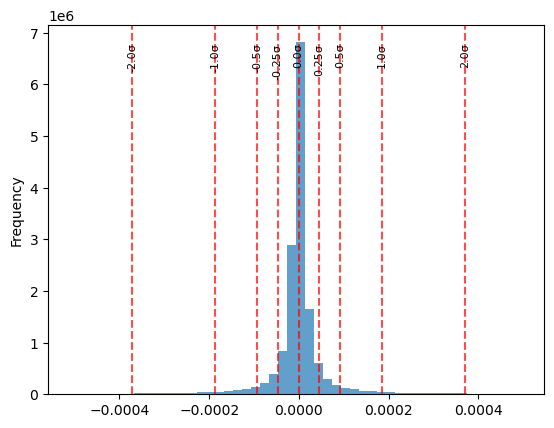

In [ ]:
import matplotlib.pyplot as plt

lo, hi = merged_sumstats['mean_sad_score'].quantile([0.01, 0.99])
ax=s.plot(kind='hist', range=(lo, hi), bins=50, alpha=0.7)
multiples = np.array([-2, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 2])
lines = mean + multiples * std

# add vertical lines
for m, x in zip(multiples, lines):
    plt.axvline(x, color="red", linestyle="--", alpha=0.7)
    plt.text(x, ax.get_ylim()[1]*0.95, f"{m}σ", ha="center", va="top", fontsize=8, rotation=90)

plt.savefig("result_evaluation/plots/sad_bins.svg", format="svg", bbox_inches="tight")
plt.show()


<Axes: ylabel='Frequency'>

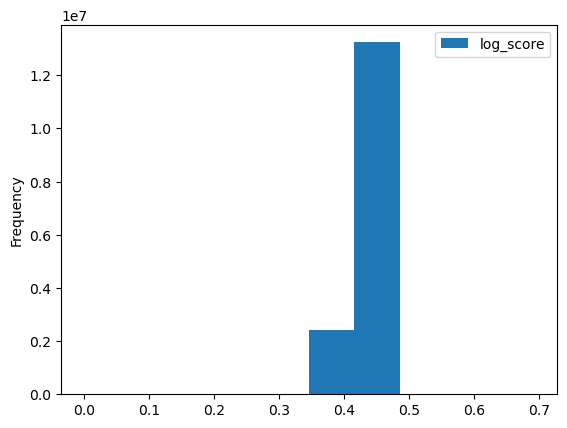

In [13]:
import numpy as np

s = merged_sumstats['mean_sad_score']

s_norm = 1 + (s - s.min()) / (s.max() - s.min())
d = np.log(s_norm)
pd.DataFrame({'log_score':d}).plot(kind='hist')

In [12]:
d.min()
s_norm.min()

0.0

<Axes: ylabel='Frequency'>

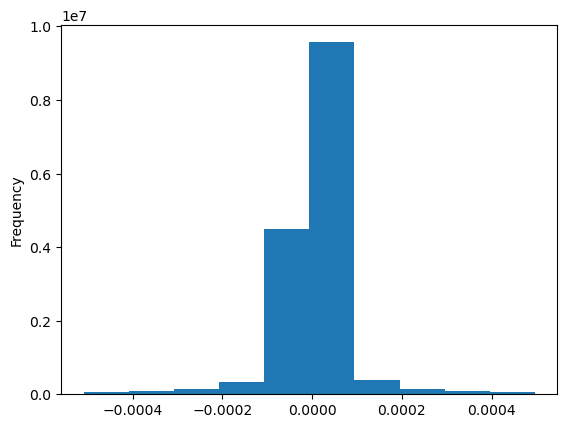

In [ ]:
lo, hi = merged_sumstats['mean_sad_score'].quantile([0.01, 0.99])
merged_sumstats['mean_sad_score'].plot(kind='hist', range=(lo, hi))

In [9]:
merged_sumstats['score_bin'] = pd.qcut(merged_sumstats['mean_sad_score'], q=10)

/tmp/ipykernel_2274123/901142806.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = merged_sumstats.loc[s.index].groupby('score_bin')['mean_sad_score']


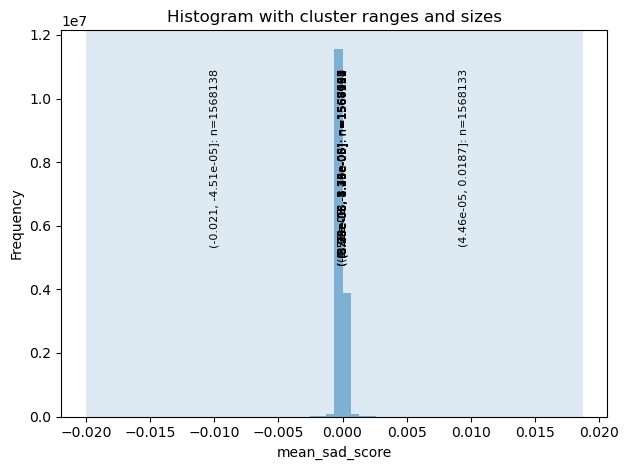

: 

In [ ]:
import matplotlib.pyplot as plt

s = merged_sumstats['mean_sad_score'].dropna()
ax = s.plot(kind='hist', bins=60, density=False, alpha=0.5)

g = merged_sumstats.loc[s.index].groupby('score_bin')['mean_sad_score']
for cid, vals in g:
    lo, hi = vals.min(), vals.max()
    ax.axvspan(lo, hi, alpha=0.15)
    ax.text((lo+hi)/2, ax.get_ylim()[1]*0.9, f"{cid}: n={len(vals)}",
            ha='center', va='top', fontsize=8, rotation=90)

ax.set_xlabel('mean_sad_score'); ax.set_title('Histogram with cluster ranges and sizes')
plt.tight_layout(); plt.show()


In [ ]:
merged_sumstats['score'].plot(kind='hist', range=(lo, hi))

<Axes: ylabel='Frequency'>

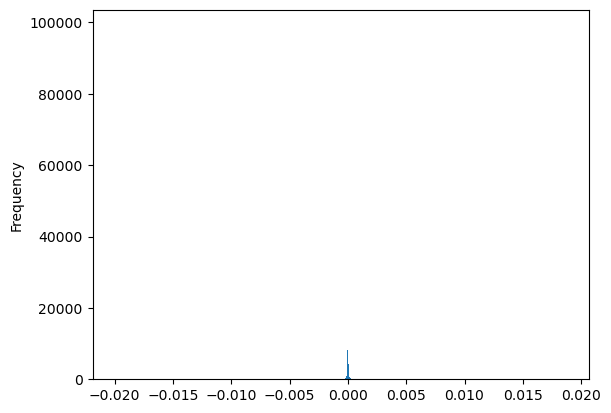

In [ ]:


merged_sumstats['mean_sad_score'].plot(kind='hist', bins='fd')

### Build Pipeline

In [ ]:
from config import BIN_COL, FDR_THRESHOLD, STD_BIN_LABELS, STD_BINS
from filtering import get_mean_sad_z_score


logger.info(f'Starting Deepcast with sFDR on {date.today()}')

logger.info(f'Retrieving sumstats file name for Phenotype {phen_id}')
sumstats_file: str = filename if filename is not None else retrieve_sumstats_filename(phen_id)
n_cases = retrieve_n_cases(phen_id)

logger.info(f'Sumstats file: {sumstats_file}.')
sumstats: pd.DataFrame = read_in_sumstats(sumstats_file, column_names)

tracklist: list[int] = read_in_tracklist(phen_id)
logger.info(f'Tracklist: {tracklist}')

logger.info('Merging Sumstats with tracklists.')
merged_sumstats = merge_sumstats_enformer_tracks(sumstats, tracklist)

logger.info('Identifying deepcast-relevant SNPs:')
merged_sumstats['in_coding_region'] = identify_coding_snps(merged_sumstats)
coding_snps_deepcast: int = merged_sumstats['in_coding_region'].sum()
logger.info(f'Found {coding_snps_deepcast} coding SNPs.')

logger.info('Making SNP buckets based on SAD scores:')
merged_sumstats['mean_sad_z_score'] = get_mean_sad_z_score(merged_sumstats, tracklist)
merged_sumstats[BIN_COL] = pd.cut(merged_sumstats[merged_sumstats['in_coding_region']==False]['mean_sad_z_score'], bins=STD_BINS, labels=STD_BIN_LABELS)
merged_sumstats[BIN_COL] = merged_sumstats[BIN_COL].cat.add_categories(['coding'])
merged_sumstats[BIN_COL] = merged_sumstats[BIN_COL].fillna('coding')

# TODO why 12 categories?!
logger.info(f"{len(STD_BINS)} bins with counts:") # since it's interval borders, it counts one too muchj, but we also need to add 1 for 'coding'
logger.info(f"{merged_sumstats[BIN_COL].value_counts().sort_index()}")


17:33:30 - __main__ - INFO - Starting Deepcast with sFDR on 2025-10-30
17:33:30 - __main__ - INFO - Retrieving sumstats file name for Phenotype 4939
17:33:30 - __main__ - INFO - Sumstats file: icd10-K60-both_sexes.tsv.bgz.
17:33:30 - input_output - INFO - Reading in sumstats
17:33:30 - input_output - DEBUG - sumstats path /cluster/work/boeva/lrabuzin/deepcast/data/ukbb_phens/icd10_sumstats_/icd10-K60-both_sexes.tsv.bgz


/cluster/work/boeva/lrabuzin/deepcast/src/input_output.py:62: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  sumstats = pd.concat(pd.read_csv(file, sep="\t", usecols=selected_columns, chunksize=100000), ignore_index=True)
17:34:17 - input_output - DEBUG - Found 5125720 of 28987534 N/A rows in column neglog10_pval_EUR.
17:34:17 - input_output - INFO - Dropping N/A rows and resetting the index
17:34:19 - input_output - INFO - Reading in tracklist.
17:34:19 - input_output - DEBUG - Tracklist path /cluster/work/boeva/lrabuzin/deepcast/data/tracklists/tracks_phen4939.csv.
17:34:19 - __main__ - INFO - Tracklist: [59, 186, 360, 420]
17:34:19 - __main__ - INFO - Merging Sumstats with tracklists.
17:34:19 - merge_sumstats_enformer_tracks - INFO - Merging sumstats with enformer SAD tracks
17:34:19 - merge_sumstats_enformer_tracks - DEBUG - SAD columns: ['SAD59', 'SAD186', 'SAD360', 'SAD420']
17:34:33 - merge_sumstats_enformer_tracks - INFO -

In [31]:
STD_BINS

[-inf, -2, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 2, inf]

In [26]:
merged_sumstats.head(12)

,chr,pos,ref,alt,neglog10_pval_EUR,snp,SAD59,SAD186,SAD360,SAD420,in_coding_region,mean_sad_z_score,sad_z_score_bin
0,1,11063,T,G,0.22460,rs561109771,-7.595000e-03,-0.000362,0.000080,-0.000619,False,-6.259007,<-2σ
1,1,533573,G,A,0.62720,rs575442534,2.060000e-05,0.000011,0.000083,0.000018,False,0.304134,"[0.25σ, 0.5σ]"
2,1,541944,T,C,0.05973,rs568792105,-2.390000e-05,-0.000024,-0.000077,-0.000034,False,-0.307797,"[-0.5σ, -0.25σ]"
3,1,672798,G,A,0.12530,rs538740799,3.600000e-07,-0.000036,0.000011,-0.000003,False,0.008739,"[0σ, 0.25σ]"
4,1,691545,A,T,0.05747,rs548729314,6.070000e-05,0.000021,0.000016,0.000031,False,0.140317,"[0σ, 0.25σ]"
5,1,692794,CA,C,0.22400,rs530212009,-7.500000e-05,0.000365,0.000242,0.000327,False,1.255101,"[1σ, 2σ]"
6,1,693731,A,G,0.07843,rs12238997,7.150000e-06,0.000226,-0.000098,-0.000039,False,-0.180203,"[-0.25σ, 0σ]"
7,1,706425,C,T,0.12800,rs529439608,-2.842000e-04,-0.000005,-0.000033,-0.000105,False,-0.410064,"[-0.5σ, -0.25σ]"
8,1,706992,C,T,1.65800,rs533042087,-2.245000e-04,-0.000022,-0.000011,-0.000044,False,-0.256715,"[-0.5σ, -0.25σ]"
9,1,707014,A,C,1.68200,rs141817527,-9.614000e-05,0.000032,-0.000001,-0.000021,False,-0.070553,"[-0.25σ, 0σ]"


In [56]:
from fdr_adjust_pvals import perform_sfdr


logger.info(f"Perform sFDR:")
fdr_adjusted_sumstats = perform_sfdr(merged_sumstats)

17:52:12 - __main__ - INFO - Perform sFDR:
17:52:12 - fdr_adjust_pvals - INFO - Performing sFDR


/cluster/work/boeva/lrabuzin/deepcast/src/fdr_adjust_pvals.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin, sub_df in sumstats.groupby(BIN_COL)
17:52:14 - fdr_adjust_pvals - INFO - Perform FDR by stratum:
17:52:56 - fdr_adjust_pvals - INFO - Collect non-empty chromosome dataframes.
17:52:56 - fdr_adjust_pvals - INFO - Merge chromosome dataframes.
17:52:57 - fdr_adjust_pvals - INFO - Merged data contains 15681371 SNPs


In [57]:
fdr_adjusted_sumstats.head()

,chr,pos,ref,alt,neglog10_pval_EUR,snp,SAD59,SAD186,SAD360,SAD420,in_coding_region,mean_sad_z_score,sad_z_score_bin,pval,adjusted_pval
0,1,11063,T,G,0.22460,rs561109771,-0.007595,-0.000362,0.000080,-0.000619,False,-6.259007,<-2σ,0.596211,0.972390
1,1,746211,A,AG,0.05404,rs201075335,-0.004982,-0.002792,-0.001030,-0.001740,False,-10.496024,<-2σ,0.882999,0.986407
2,1,749963,T,TAA,0.02120,rs529266287,-0.000722,-0.000831,-0.000430,-0.000840,False,-3.221585,<-2σ,0.952357,0.994337
3,1,751488,G,GA,0.21080,rs200141114,-0.004180,-0.001883,-0.000659,-0.001634,False,-7.982097,<-2σ,0.615460,0.972390
4,1,772310,G,GTT,0.09527,rs199975097,-0.001748,-0.001419,-0.000044,0.000116,False,-2.352389,<-2σ,0.803027,0.977817


In [29]:
fdr_adjusted_sumstats[fdr_adjusted_sumstats[BIN_COL]=='coding'].head()

,chr,pos,ref,alt,neglog10_pval_EUR,snp,SAD59,SAD186,SAD360,SAD420,in_coding_region,mean_sad_z_score,sad_z_score_bin,pval,adjusted_pval
15267907,1,713698,C,T,0.09004,rs555211605,0.000957,0.000383,0.000159,0.000334,True,1.786913,coding,0.812756,0.967705
15267908,1,753541,G,A,0.11650,rs2073813,-0.000359,-0.000352,-0.000132,-0.000287,True,-1.183764,coding,0.764716,0.961684
15267909,1,754105,C,T,0.25940,rs12184325,-0.000021,-0.000035,-0.000016,-0.000070,True,-0.151151,coding,0.550301,0.959335
15267910,1,754121,T,G,0.21400,rs12184335,0.000086,-0.000387,-0.000155,-0.000298,True,-0.958356,coding,0.610942,0.959335
15267911,1,754163,T,C,0.20100,rs12184336,0.000126,-0.000061,0.000028,-0.000156,True,0.007108,coding,0.629506,0.959335


In [48]:
fdr_adjusted_sumstats['adjusted_pval'].nsmallest(10)

81388       0.000078
81389       0.000078
15210054    0.000108
259440      0.000118
259441      0.000118
15059084    0.001344
117620      0.002246
15384345    0.002377
15384358    0.002377
15384359    0.002377
Name: adjusted_pval, dtype: float64

In [50]:
len(fdr_adjusted_sumstats[fdr_adjusted_sumstats['adjusted_pval']<0.05])/len(fdr_adjusted_sumstats)

0.00027988624208941934

In [59]:
len(fdr_adjusted_sumstats[fdr_adjusted_sumstats['adjusted_pval']<0.05])

4389

In [66]:
len(fdr_adjusted_sumstats[fdr_adjusted_sumstats['adjusted_pval']<0.0025])

151

In [55]:
fdr_adjusted_sumstats[fdr_adjusted_sumstats['adjusted_pval']<0.0005]

,chr,pos,ref,alt,neglog10_pval_EUR,snp,SAD59,SAD186,SAD360,SAD420,in_coding_region,mean_sad_z_score,sad_z_score_bin,pval,adjusted_pval
81388,11,10380180,G,GT,8.959,rs36036016,-0.001932,-0.000041,-0.000407,-0.003075,False,-5.448003,<-2σ,1.099006e-09,0.000078
81389,11,10381391,ATAACTT,A,9.052,rs71034763,0.000325,-0.002222,-0.000946,-0.002373,False,-6.380533,<-2σ,8.871560e-10,0.000078
259440,11,10383037,C,CA,9.080,rs137856246,-0.000773,-0.002022,0.000116,0.000596,False,-1.117939,"[-2σ, -1σ]",8.317638e-10,0.000118
259441,11,10383749,TA,T,8.909,rs34609123,-0.000396,-0.001501,-0.000007,0.000328,False,-1.088047,"[-2σ, -1σ]",1.233105e-09,0.000118
15210054,11,10385127,TACGAATGA,T,9.101,rs147646513,0.001251,0.001617,0.001471,0.002796,False,9.180246,>2σ,7.925013e-10,0.000108


In [ ]:
fdr_adjusted_sumstats[fdr_adjusted_sumstats['adjusted_pvals']<0.05][BIN_COL].value_counts().sort_index()

sad_z_score_bin
<-2σ                 76
[-2σ, -1σ]           84
[-1σ, -0.5σ]        116
[-0.5σ, -0.25σ]     176
[-0.25σ, 0σ]       1609
[0σ, 0.25σ]        1615
[0.25σ, 0.5σ]       203
[0.5σ, 1σ]          126
[1σ, 2σ]             92
>2σ                  61
coding              231
Name: count, dtype: int64